# Load Data
To show proof of concept only considering sequences shorter than 32 amino acids. Also experiments suggest to apply a sliding overlapping window of size 3 to the input seqeunces. In the sense of  NLP this artificially creates a corpus consisting of much more different words (>7000 different ngrams compared to 20 amino acids). There has been a lot of research in respresenting protein sequences as sentences of  biological words. 

(393732, 7)
88751


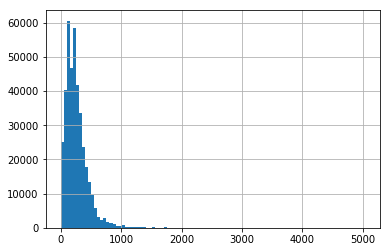

In [1]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

df = pd.read_csv('../input/2018-06-06-ss.cleaned.csv')
df.len.hist(bins=100)
print(df.shape)

def seq2ngrams(seqs, n=3):
    return np.array([[seq[i:i+n] for i in range(len(seq))] for seq in seqs])

maxlen_seq = 128
input_seqs, target_seqs = df[['seq', 'sst3']][(df.len <= maxlen_seq) & (~df.has_nonstd_aa)].values.T
input_grams = seq2ngrams(input_seqs)
print(len(input_seqs))

# Preprocessing
use preprocessing tools for text from keras to encode input sequence as word rank numbers  and target sequence as one hot. To ensure easy to use training and testing, all sequences are padded with zeros to the maximum sequence length (in our case 32).

In [2]:
from keras.preprocessing import text, sequence
from keras.preprocessing.text import Tokenizer
from keras.utils import to_categorical
from tensorflow.keras import models, layers

tokenizer_encoder = Tokenizer()
tokenizer_encoder.fit_on_texts(input_grams)
input_data = tokenizer_encoder.texts_to_sequences(input_grams)
input_data = sequence.pad_sequences(input_data, maxlen=maxlen_seq, padding='post')

tokenizer_decoder = Tokenizer(char_level=True)
tokenizer_decoder.fit_on_texts(target_seqs)
target_data = tokenizer_decoder.texts_to_sequences(target_seqs)
target_data = sequence.pad_sequences(target_data, maxlen=maxlen_seq, padding='post')
target_data = to_categorical(target_data)
input_data.shape, target_data.shape

Using TensorFlow backend.


((88751, 128), (88751, 128, 4))

# Build model
This example is motivated by the NLP-task of POS-tagging. 

In [3]:
from keras.models import Model, Input
from keras.layers import LSTM, Embedding, Dense, TimeDistributed, Bidirectional

n_words = len(tokenizer_encoder.word_index) + 1
n_tags = len(tokenizer_decoder.word_index) + 1
print(n_words, n_tags)

input = Input(shape=(maxlen_seq,))
x = Embedding(input_dim=n_words, output_dim=128, input_length=maxlen_seq)(input)
x = Bidirectional(LSTM(units=64, return_sequences=True, recurrent_dropout=0.1))(x)
y = TimeDistributed(Dense(n_tags, activation="softmax"))(x)
model = Model(input, y)
model.summary()

8421 4
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
input_1 (InputLayer)         (None, 128)               0         
_________________________________________________________________
embedding_1 (Embedding)      (None, 128, 128)          1077888   
_________________________________________________________________
bidirectional_1 (Bidirection (None, 128, 128)          98816     
_________________________________________________________________
time_distributed_1 (TimeDist (None, 128, 4)            516       
Total params: 1,177,220
Trainable params: 1,177,220
Non-trainable params: 0
_________________________________________________________________


# Train and evaluate model
The model is trained such that the categorical crossentropy is minimized. For evalutation also Q3-accuracy is computed, by computing the accuracy only for coding characters. 

In [4]:
from sklearn.model_selection import train_test_split
from keras.metrics import categorical_accuracy
from keras import backend  as K
import tensorflow as tf


def q3_acc(y_true, y_pred):
    y = tf.argmax(y_true, axis=-1)
    y_ = tf.argmax(y_pred, axis=-1)
    mask = tf.greater(y, 0)
    return K.cast(K.equal(tf.boolean_mask(y, mask), tf.boolean_mask(y_, mask)), K.floatx())

model.compile(optimizer="rmsprop", loss="categorical_crossentropy", metrics=["accuracy", q3_acc])

X_train, X_test, y_train, y_test = train_test_split(input_data, target_data, test_size=.4, random_state=0)
seq_train, seq_test, target_train, target_test = train_test_split(input_seqs, target_seqs, test_size=.4, random_state=0)

history = model.fit(X_train, y_train, batch_size=256, epochs=11, validation_data=(X_test, y_test), verbose=1)

Train on 53250 samples, validate on 35501 samples
Epoch 1/11
53250/53250 [==============================] - 211s 4ms/step - loss: 0.4695 - acc: 0.8003 - q3_acc: 0.6846 - val_loss: 0.3482 - val_acc: 0.8558 - val_q3_acc: 0.7715
Epoch 2/11
53250/53250 [==============================] - 208s 4ms/step - loss: 0.3129 - acc: 0.8744 - q3_acc: 0.7998 - val_loss: 0.3198 - val_acc: 0.8698 - val_q3_acc: 0.7936
Epoch 3/11
53250/53250 [==============================] - 209s 4ms/step - loss: 0.2783 - acc: 0.8900 - q3_acc: 0.8247 - val_loss: 0.2702 - val_acc: 0.8940 - val_q3_acc: 0.8320
Epoch 4/11
53250/53250 [==============================] - 208s 4ms/step - loss: 0.2556 - acc: 0.8998 - q3_acc: 0.8403 - val_loss: 0.2730 - val_acc: 0.8909 - val_q3_acc: 0.8271
Epoch 5/11
53250/53250 [==============================] - 208s 4ms/step - loss: 0.2389 - acc: 0.9067 - q3_acc: 0.8513 - val_loss: 0.2436 - val_acc: 0.9059 - val_q3_acc: 0.8509
Epoch 6/11
53250/53250 [==============================] - 209s 4ms/ste

In [10]:
model.save("./model.keras")

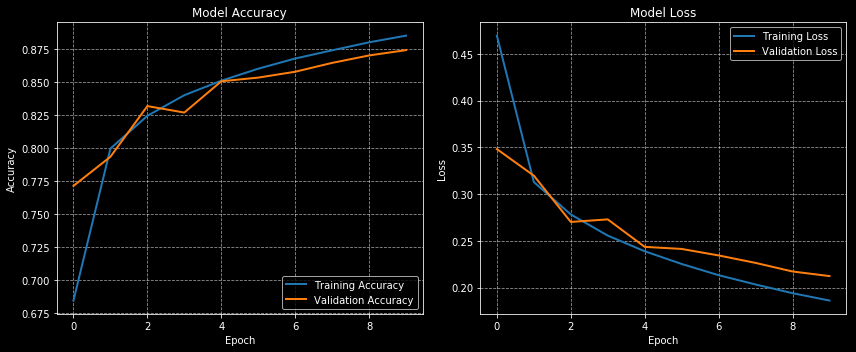

In [8]:
plt.figure(figsize=(12, 5))
plt.style.use('dark_background')
# Plot 1: Accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['q3_acc'][:10], label='Training Accuracy', color='#1f77b4', lw=2)
plt.plot(history.history['val_q3_acc'][:10], label='Validation Accuracy', color='#ff7f0e', lw=2)
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.6)

# Plot 2: Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'][:10], label='Training Loss', color='#1f77b4', lw=2)
plt.plot(history.history['val_loss'][:10], label='Validation Loss', color='#ff7f0e', lw=2)
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

# Results
For this small example, the model trained very fast and achieves quite reasonable Q3-accuaracies. In the following three training and three testing examples are shown. Each image shows the softmax activation (red) on top of the underlying one hot ground truth (blue).

training
---
Input: MGDKPIWEQIGSSFINHYYQLFDNDRTQLGAIYIDASCLTWEGQQFQGKAAIVEKLSSLPFQKIQHSITAQDHQPTPDSCIISMVVGQLKADEDPIMGFHQEFLLKNINDAWVCTNDMFRLALHNFG
Target: CCCCCHHHHHHHHHHHHHHHHHHHCHHHHHHHCCCCCEEEECCEEEECHHHHHHHHHHCCCCCEEEEEEEEEEEECCCCCEEEEEEEEEEECCCCCEEEEEEEEEEECCCCEEEEEEEEEEECCCCC
Result: CCCCCHHHHHHHHHHHHHHHHHHHHHHHHHHEEEEEEEEEECCEEEECHHHHHHHHHHCCCCCEEEEEEEEEEEECCCCCEEEEEEEEEEECCCCCEEEEEEEEEEECCCEEEEEEEEEEECCCCCC


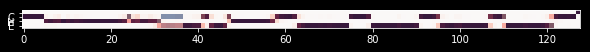

---
Input: SRGTQTE
Target: CEEEECC
Result: CCCCCCC


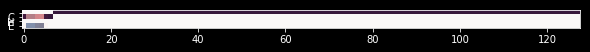

---
Input: MKEEKRSSTGFLVKQRAFLKLYMITMTEQERLYGLKLLKVLQSEFKEIGFKPNHTEVYRSLHELLDDGILKQIKVKKEGAKLQEVVLYQFKDYEAAKLYKKQLKVELDRCKKLIEKALSDNF
Target: CCCCCCCCCCCCCCHHHHHHHHHHHHHHCCCEECCCCHHHHHHHHCCCCCCCCHHHHHHHHHHHHHCCCEEEEECCCCCCCCCCCEEEEECCHHHHHHHHHHHHHHHHHHHHHHHHHHHHHC
Result: CCCCCCCCCCCCCCHHHHHHHHHHHHHHHHCCECHHHHHHHHHHHHCCCCCCCHHHHHHHHHHHHHHCCEEEEEECCCCCCCCCEEEEECCCHHHHHHHHHHHHHHHHHHHHHHHHHHHHHC


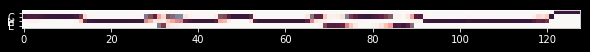

testing
---
Input: MKRQKRDRLERAHQRGYQAGIAGRSKEMCPYQTLNQRSQWLGGWREAMADRVVMAHHHHHH
Target: CCCCCHHHHHHHHHHHHHHHHCCCCCCCCCCCCHHHHHHHHHHHHHHHHHCCCCCCCCCCC
Result: CCCCCHHHHHHHHHHHHHHHHHCCHHHCCCCHHHHHHHHHHCHHHHHHHHHCCCCCCCCCC


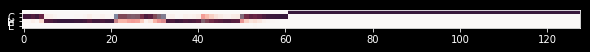

---
Input: YCQKWMWTCDEERKCCEGLVCRLWCKRIINM
Target: CCCCCCCECCCCCCCCCCCECCCECECCCCC
Result: CCCCCCCCCCCCCCEECCCCCEEEEEEEEEC


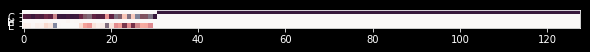

---
Input: TEFSEEQKRTLDLLFLFDRRMTEERRRWLSQRLGLNEEQIERWFRRKEQQI
Target: CCCCCCHHHHHHHHHHHHHHHHHHHHHHHHHHCCCCHHHHHHHHHCCCCCC
Result: CCCCHHHHHHHHHHHHHHHHHHHHHHHHHHHHHCCCHHHHHHHHHHCCCCC


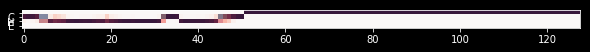

In [6]:
def onehot_to_seq(oh_seq, index):
    s = ''
    for o in oh_seq:
        i = np.argmax(o)
        if i != 0:
            s += index[i]
        else:
            break
    return s

def plot_results(x, y, y_):
    print("---")
    print("Input: " + str(x))
    print("Target: " + str(onehot_to_seq(y, revsere_decoder_index).upper()))
    print("Result: " + str(onehot_to_seq(y_, revsere_decoder_index).upper()))
    fig = plt.figure(figsize=(10,2))
    plt.imshow(y.T, cmap='Blues')
    plt.imshow(y_.T, cmap='Reds', alpha=.5)
    plt.yticks(range(4), [' '] + [revsere_decoder_index[i+1].upper() for i in range(3)])
    plt.show()
    
revsere_decoder_index = {value:key for key,value in tokenizer_decoder.word_index.items()}
revsere_encoder_index = {value:key for key,value in tokenizer_encoder.word_index.items()}

N=3
y_train_pred = model.predict(X_train[:N])
y_test_pred = model.predict(X_test[:N])
print('training')
for i in range(N):
    plot_results(seq_train[i], y_train[i], y_train_pred[i])
print('testing')
for i in range(N):
    plot_results(seq_test[i], y_test[i], y_test_pred[i])

AttributeError: Unknown property ms

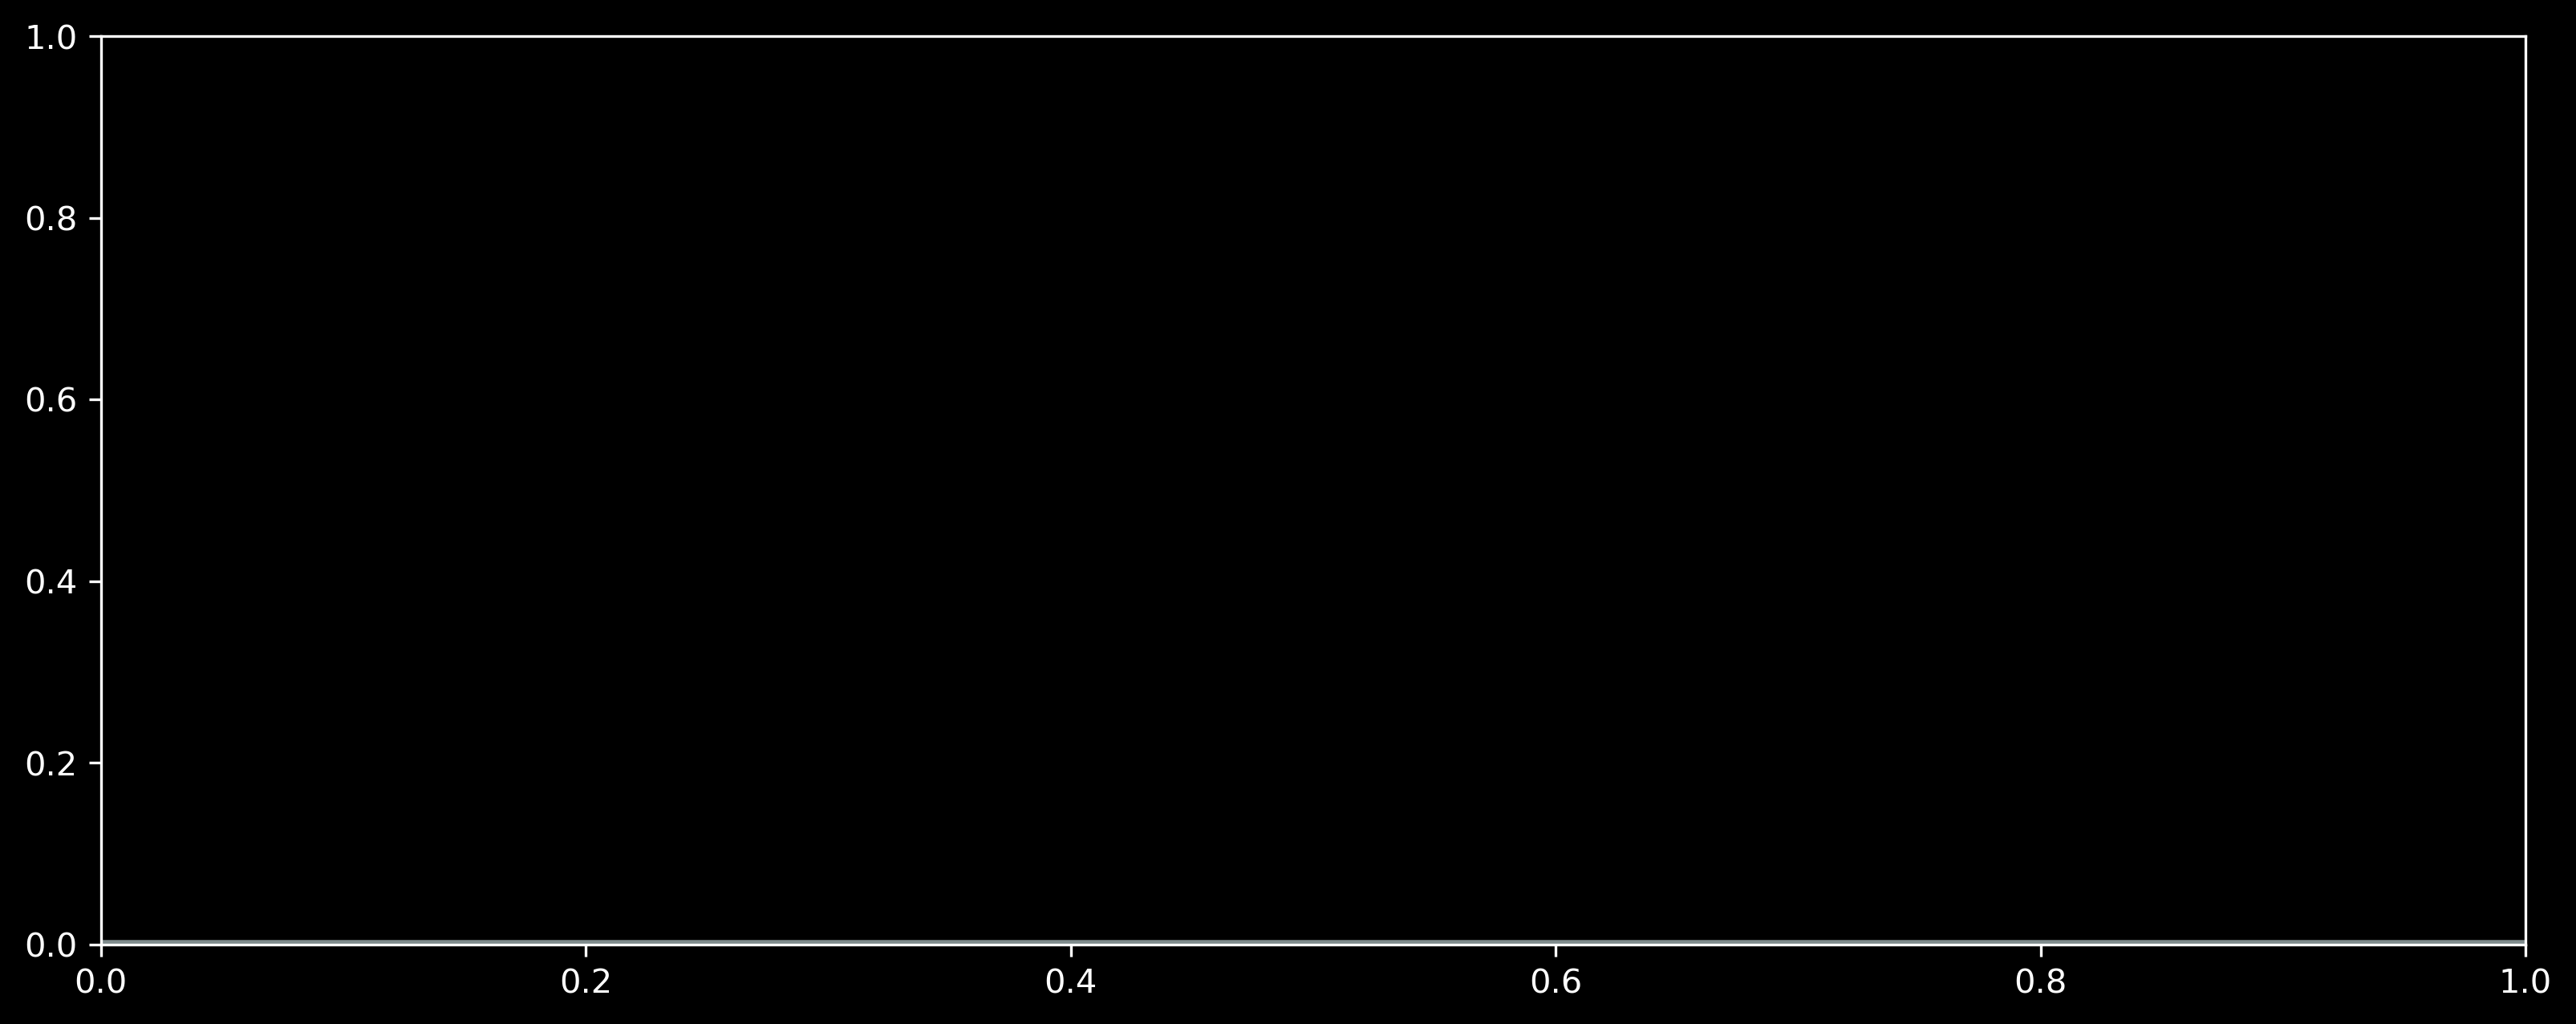

In [7]:
import matplotlib.pyplot as plt

# Configuration du style sombre pour un rendu pro
plt.style.use('dark_background')
fig, ax = plt.subplots(figsize=(13, 5), dpi=300)

# Données de la frise chronologique
methods = [
    {
        "title": "MÉTHODES EXPÉRIMENTALES\n(Cristallographie, RMN)",
        "accuracy": "Précision : ~100%",
        "time": "Temps : Mois / Années",
        "desc": "Ultra-précis mais extrêmement\nlourd, long et coûteux.",
        "color": "#e74c3c" # Rouge
    },
    {
        "title": "MÉTHODES STATISTIQUES\n(Chou-Fasman, GOR)",
        "accuracy": "Précision : ~50-60%",
        "time": "Temps : Rapide",
        "desc": "Basé sur la fréquence des acides\naminés. Limité sans contexte.",
        "color": "#f39c12" # Orange
    },
    {
        "title": "MÉTHODES PAR HOMOLOGIE\n(Template-Based)",
        "accuracy": "Précision : Variable",
        "time": "Temps : Rapide",
        "desc": "Efficace si une protéine similaire\nexiste déjà dans les bases.",
        "color": "#2ecc71" # Vert
    }
]

# Tracé de la ligne centrale de la frise
ax.axhline(y=0, color='#7f8c8d', linestyle='-', linewidth=3, zorder=1)

# Espacement horizontal des blocs
x_positions = [1, 3, 5]

for i, method in enumerate(methods):
    x = x_positions[i]
    
    # Dessiner la flèche de liaison entre les blocs (sauf pour le dernier)
    if i < len(methods) - 1:
        ax.annotate('', xy=(x_positions[i+1] - 0.4, 0), xytext=(x + 0.4, 0),
                    arrowprops=dict(arrowstyle="->", color="#34495e", lw=3, ms=10))
        
    # Points d'ancrage sur la ligne
    ax.scatter(x, 0, color=method["color"], s=150, zorder=3, edgecolors='white', linewidths=2)
    
    # Texte de la boîte
    box_text = f"{method['title']}\n\n🟢 {method['accuracy']}\n⏳ {method['time']}\n\n💡 {method['desc']}"
    
    # Affichage alternatif (haut et bas) pour donner du dynamisme visuel
    y_text = 0.4 if i % 2 == 0 else -1.2
    
    ax.text(x, y_text, box_text, fontsize=10, fontweight='medium', color='white',
            bbox=dict(boxstyle="round,pad=0.8", facecolor='#1e1e1e', 
                      edgecolor=method["color"], linewidth=2, alpha=0.9),
            ha='center', va='center')
    
    # Ligne de connexion entre le point et la boîte
    y_line_start = 0.05 if i % 2 == 0 else -0.05
    y_line_end = 0.15 if i % 2 == 0 else -0.4
    ax.plot([x, x], [y_line_start, y_line_end], color=method["color"], linestyle='--', lw=1.5)

# Ajustements esthétiques des axes
ax.set_xlim(0, 6)
ax.set_ylim(-1.6, 1.2)
ax.axis('off') # Masquer les axes inutiles

plt.title("ÉVOLUTION DES MÉTHODES DE PRÉDICTION AVANT L'IA", fontsize=14, fontweight='bold', pad=20, color='#3498db')
plt.tight_layout()

# Sauvegarde de l'image pour ta présentation
plt.savefig('timeline_methodes_proteines.png', bbox_inches='tight', dpi=300)
plt.show()